<a href="https://colab.research.google.com/github/aubriannaps/PCD_Assignment02/blob/main/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blurry Image


This image was run through a linear filter through this kernel:
- -2, -1, 0,
- -1.3, 0.5, 1,
- 0.3, 1, 2

This kernel was created from the kernel for image embossment =
- -2, -1, 0,
- -1, 1, 1,
- 0, 1, 2

that was slightly modified to produce stronger results within the blurry image of the trash can. It was observed that embossment emphasized the differences of pixels of the small text on the trash can, and by changing and tweaking some parts of the kernel, the difference can be increased, making the text more visible.

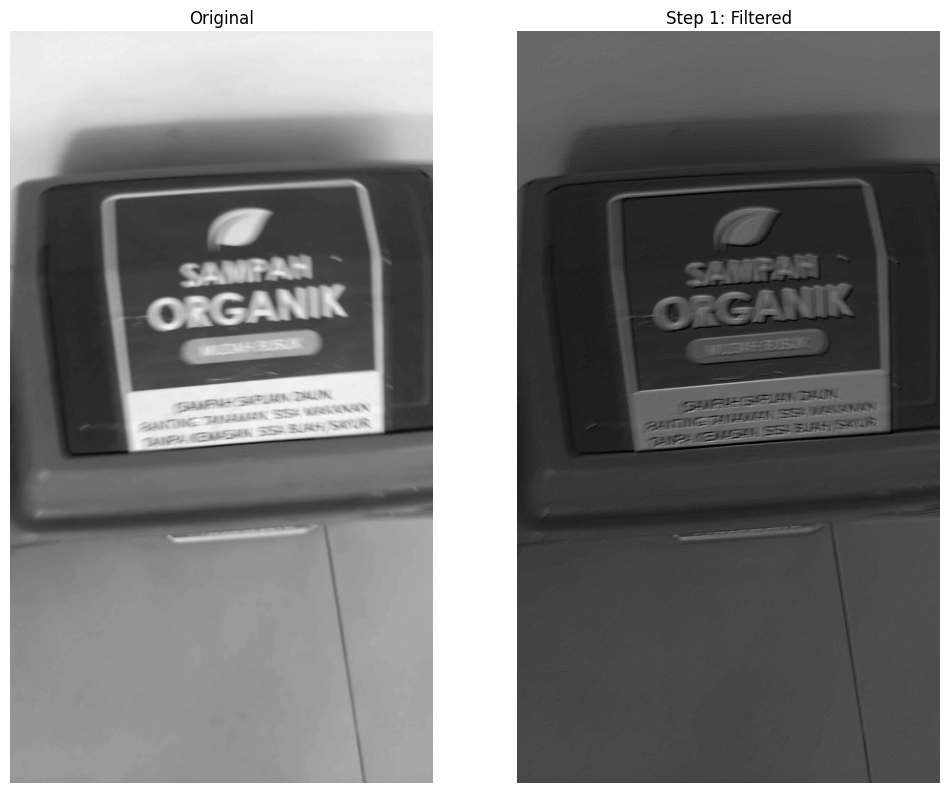

Mounted at /content/drive
Image Shape: 4096 2304


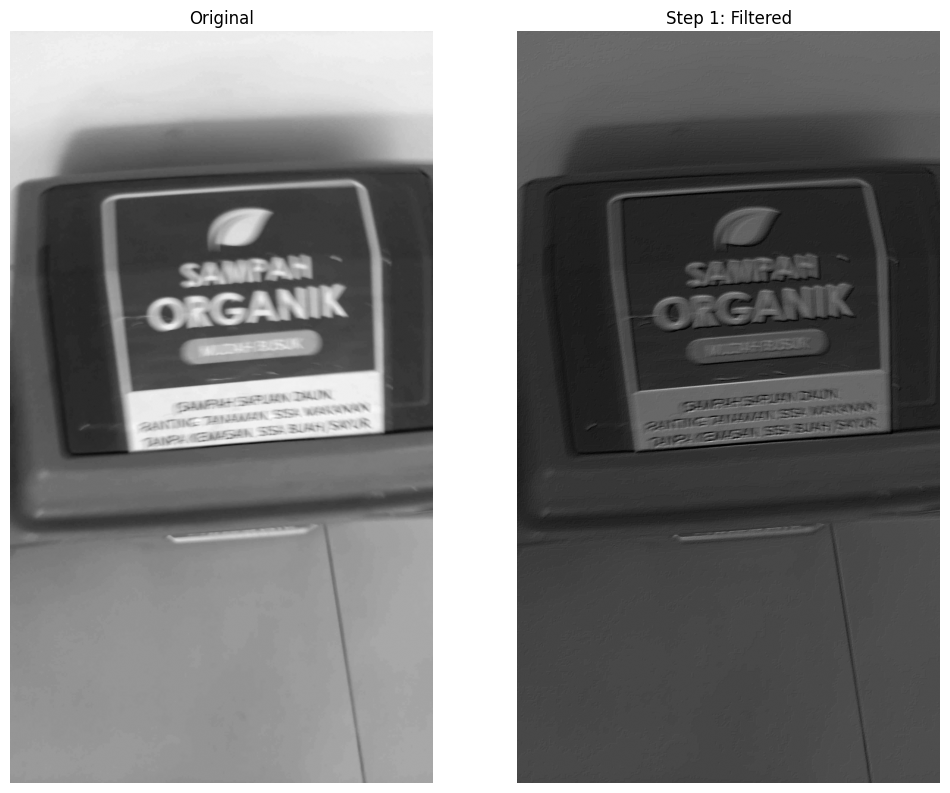

In [52]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

image_path = '/content/drive/MyDrive/PencitraanDigital/blurry.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

linear = np.array([[-2, -1, 0],
                    [-1.3, 0.5, 1],
                    [0.3, 1, 2]])

filter = cv2.filter2D(src=img, ddepth=-1, kernel=linear)

m, n = img.shape
print('Image Shape:', m, n)

images = [img, filter]
titles = ['Original', 'Step 1: Filtered']

plt.figure(figsize=(12, 12))
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()


# High Brightness Image

Firstly, histogram equilization was performed on the image. This caused some minor changes that made small changes into the contrast of the image, making some parts darker in general and making the values more equal overall.

Then, the processed image was applied a linear filter through this kernel:
- -1, -1, -1,
- -1, 8.45, -1,
- -1, -1, -1

This kernel was created from the kernel for image outline extraction =
- -1, -1, -1,
- -1, 8, -1,
- -1, -1, -1

that was slightly modified to produce stronger results. It was observed that the kernel could highlight differences in values strongly, and by changing a part of the kernel, the difference between values can be increased.

Finally, by using histogram equilization again on the image, we get a bigger contrast that also makes the image less dark overall. We can see the contrast has greatly increased and darker details are more visible due to the darkness being more equalized overall.

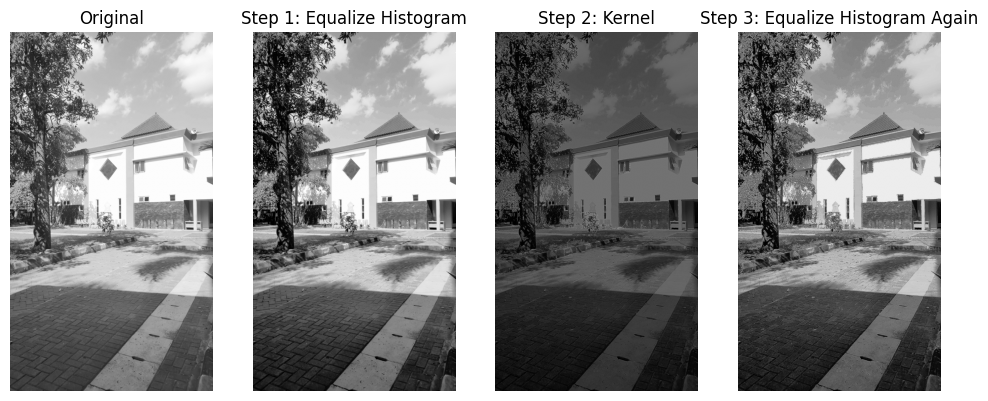

Mounted at /content/drive
Image Shape: 4096 2304


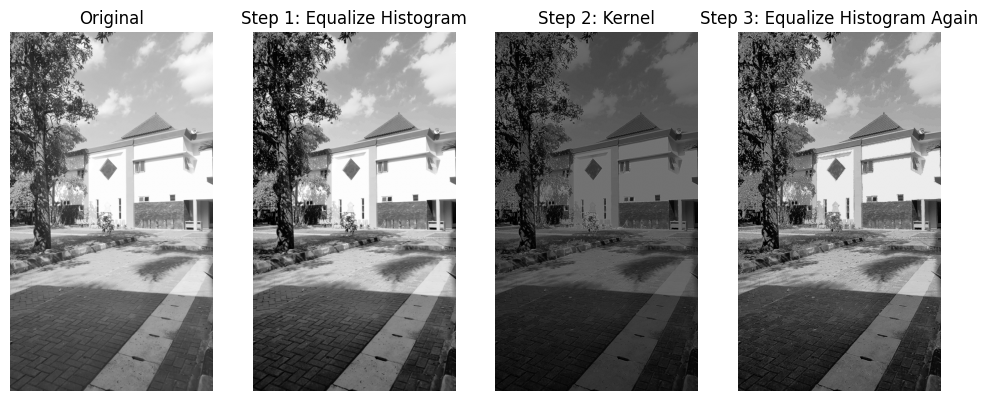

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

image_path = '/content/drive/MyDrive/PencitraanDigital/bright.jpg'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
filtered = cv2.equalizeHist(img)
linear = np.array([[-1, -1, -1],
                    [-1, 8.45, -1],
                    [-1, -1, -1]])
filter = cv2.filter2D(src=filtered, ddepth=-1, kernel=linear)

again = cv2.equalizeHist(filter)

m, n = img.shape
print('Image Shape:', m, n)

images = [img, filtered, filter, again]
titles = ['Original', 'Step 1: Equalize Histogram', 'Step 2: Kernel', 'Step 3: Equalize Histogram Again']


plt.figure(figsize=(12, 12))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

# High Darkness Image


Histogram equilization was the only image enhancement technique performed on the image. The dark details under the staircase become much clearer and more visible to the eye as the bright and dark values are more evenly spread out through the image. The image is sufficiently clear enough for details to be made out.


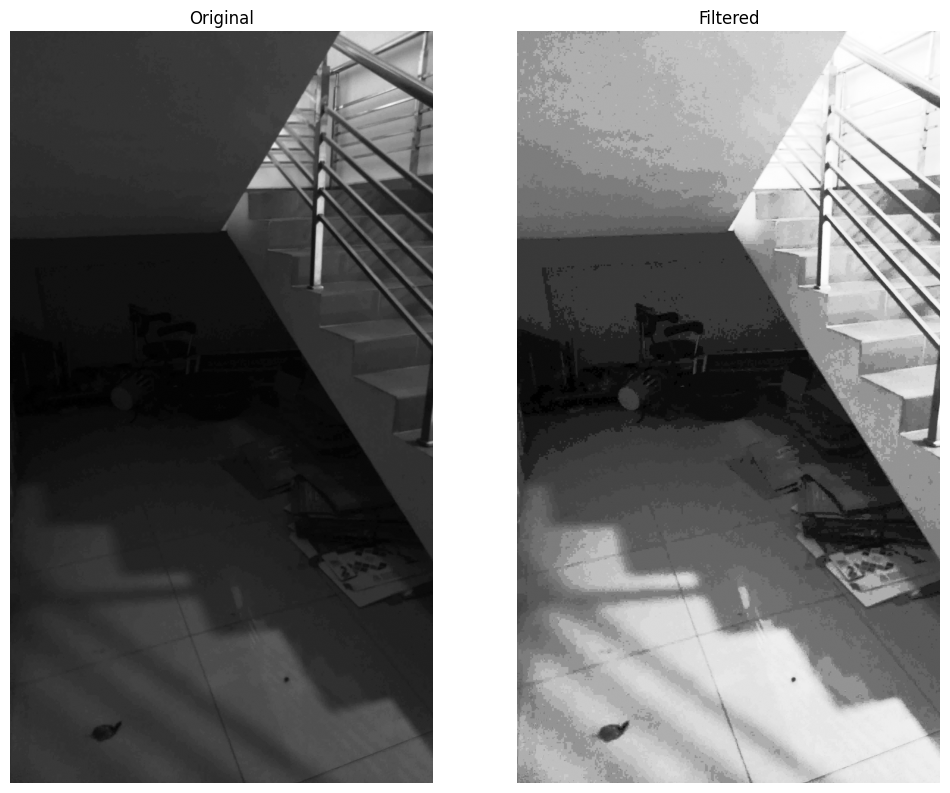

Mounted at /content/drive
Image Shape: 4096 2304


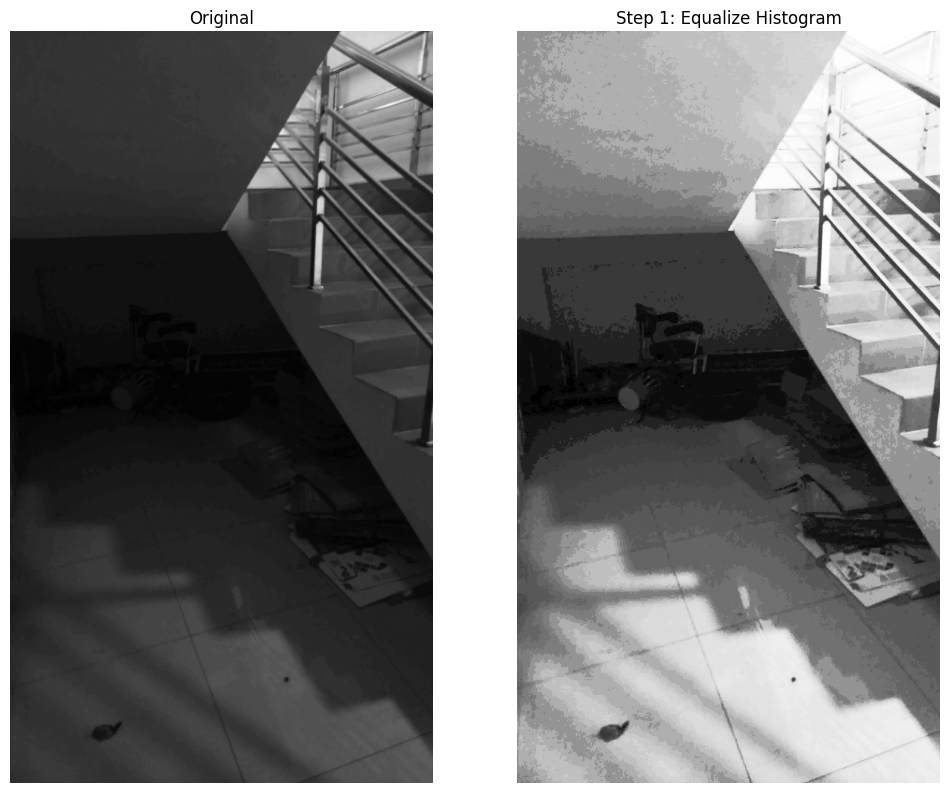

In [55]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

image_path = '/content/drive/MyDrive/PencitraanDigital/dark.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

filter = cv2.equalizeHist(img)

m, n = img.shape
print('Image Shape:', m, n)

images = [img, filter]
titles = ['Original', 'Step 1: Equalize Histogram']

plt.figure(figsize=(12, 12))
for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

# Low Contrast Image

Mounted at /content/drive
Image Shape: 3840 2160


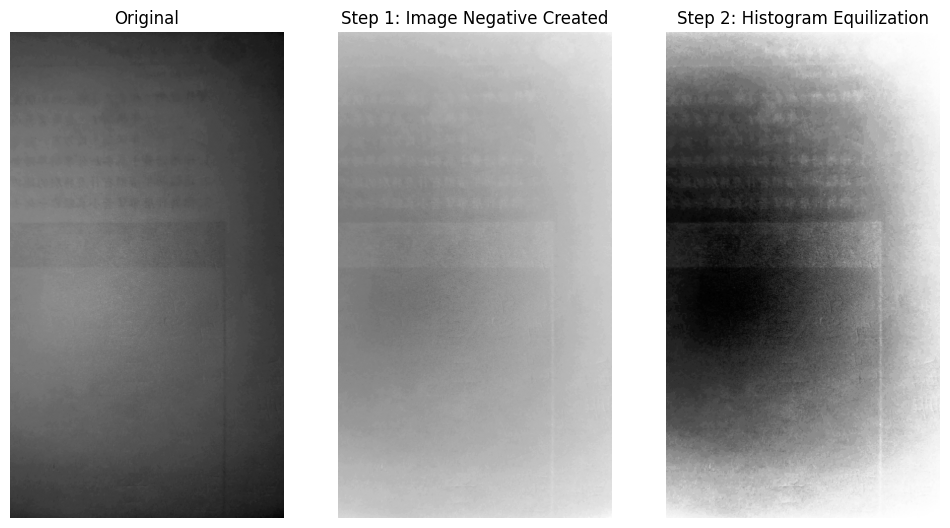

In [53]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

from google.colab import drive


drive.mount('/content/drive', force_remount=True)

image_path = '/content/drive/MyDrive/PencitraanDigital/constras.jpg'

img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

negative_image = 255 - img
filtered = cv2.equalizeHist(negative_image)

m, n = img.shape
print('Image Shape:', m, n)

images = [img, negative_image, filtered]
titles = ['Original', 'Step 1: Image Negative Created', 'Step 2: Histogram Equilization']

plt.figure(figsize=(12, 12))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()


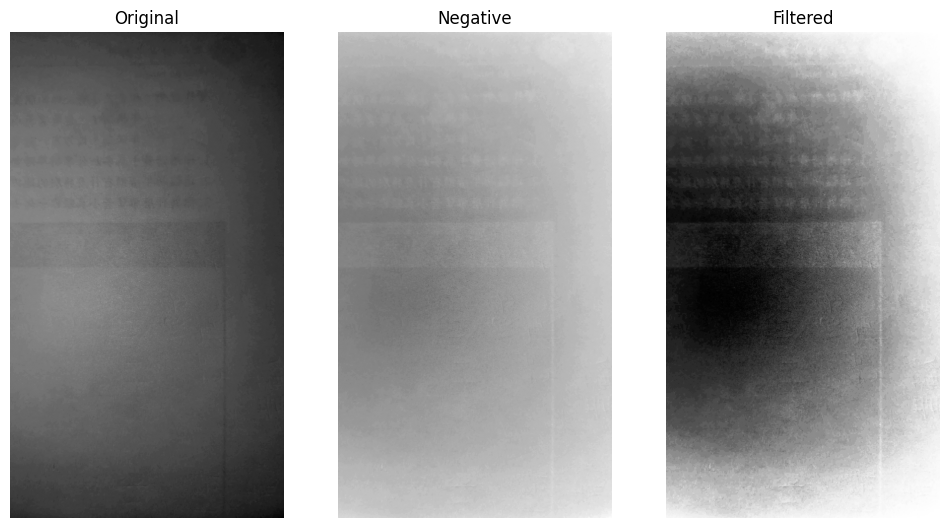

Firstly, the low contrast image was made into an image negative, reversing the bright pixels with dark and vice versa.

Then, histogram equilization is performed on the image negative, resulting in higher contrast and higher clarity and more details visible in the chinese characters.